# Production Forecasting

This notebook:
- Loads trained model
- Generates future predictions
- Creates submission file

In [ ]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 901.4/9

In [ ]:
import sys

PROJECT_PATH = "/content/drive/MyDrive/Agribora_Final"

sys.path.insert(0, PROJECT_PATH)

In [ ]:

import pandas as pd
import numpy as np
import joblib

import data_loader
import preprocessing
import feature
import model
import mlflow
import mlflow.sklearn

import validation

In [ ]:
data = data_loader.load_all_data()

df = data["agri_df"]
finalW_df = data["finalW_df"]

Loaded: agriBORA_maize_prices.csv
Shape : (239, 6)
Loaded: agriBORA_maize_prices_weeks_46_to_51.csv
Shape : (30, 6)
Loaded: kamis_maize_prices.csv
Shape : (21888, 15)
Loaded: kamis_maize_prices_raw.csv
Shape : (22525, 16)
Loaded: agriBORA_Final_Weeks_maize_price.csv
Shape : (10, 4)

All datasets loaded successfully


In [ ]:
pipeline = joblib.load("/content/drive/MyDrive/Agribora_Final/final_model.pkl")

best_model = pipeline["model"]
features = pipeline["features"]

In [ ]:
#Production forecast Function(Logic)
def predict_next_weeks(county_data, model, features):

    last = county_data.iloc[-1]

    X = last[features].values.reshape(1, -1)

    pred_diff = model.predict(X)[0]

    last_price = last["price"]

    week52_price = last_price + (0.6 * pred_diff)
    week1_price = week52_price + (2.4 * pred_diff)

    return week52_price, week1_price


In [ ]:
finalW_df["County"] = finalW_df["ID"].str.split("_").str[0]
finalW_df["Week"] = finalW_df["ID"].str.extract(r"Week_(\d+)").astype(int)

week52 = finalW_df[finalW_df["Week"] == 52]
week1 = finalW_df[finalW_df["Week"] == 1]

validation_df = week52[["County", "WholeSale"]].rename(columns={"WholeSale":"actual_w52"}).merge(
    week1[["County", "WholeSale"]].rename(columns={"WholeSale":"actual_w1"}),
    on="County"
)

pred_w52 = []
pred_w1 = []

for county in validation_df["County"]:

    c_data = feature.get_county_data(df, county)

    w52, w1 = predict_next_weeks(c_data, best_model, features)

    pred_w52.append(w52)
    pred_w1.append(w1)

validation_df["pred_w52"] = pred_w52
validation_df["pred_w1"] = pred_w1

validation_df["error_w52"] = abs(validation_df["actual_w52"] - validation_df["pred_w52"])
validation_df["error_w1"] = abs(validation_df["actual_w1"] - validation_df["pred_w1"])

validation_df["final_error"] = (validation_df["error_w52"] + validation_df["error_w1"]) / 2

print(validation_df)
print("FINAL MAE:", validation_df["final_error"].mean())

        County  actual_w52  actual_w1   pred_w52    pred_w1  error_w52  \
0       Kiambu   45.000000  46.111111  40.997156  40.545780   4.002844   
1    Kirinyaga   46.666667  47.222222  46.790482  47.272411   0.123816   
2      Mombasa   41.111111  41.111111  42.678017  42.270084   1.566906   
3      Nairobi   43.333333  45.138889  40.257620  39.061434   3.075713   
4  Uasin-Gishu   42.444444  41.555556  38.276266  38.041330   4.168179   

   error_w1  final_error  
0  5.565331     4.784088  
1  0.050189     0.087002  
2  1.158973     1.362939  
3  6.077455     4.576584  
4  3.514226     3.841202  
FINAL MAE: 2.930363042112164


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Model Persistence

The final trained model pipeline was saved using Joblib.

This allows:
- future inference
- integration into web applications
- deployment into APIs
- reproducible forecasting

## Final Validation

The model was validated using the final official AgriBORA weeks dataset.

This step simulates real-world forecasting performance before deployment.

## Production Forecasts

The final production forecasts estimate future maize wholesale prices for each county.

These forecasts can support:
- farmer selling decisions
- warehouse financing
- commodity trading
- market intelligence systems

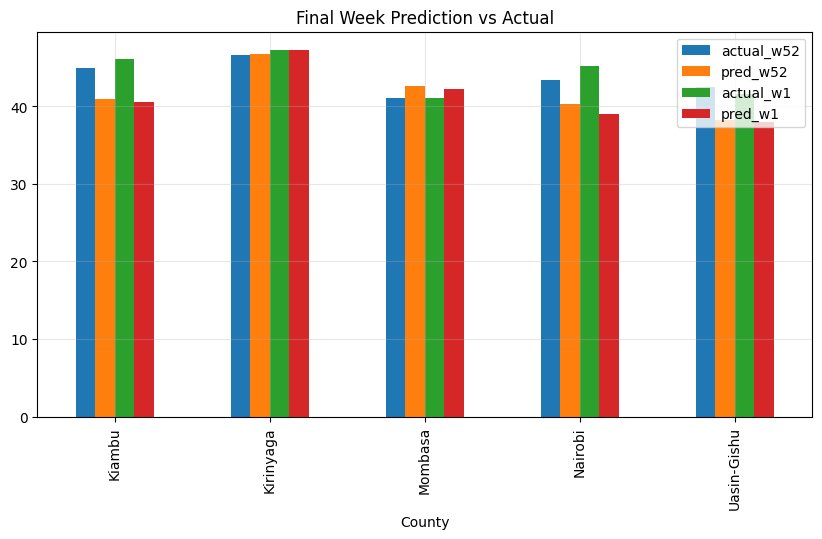

In [ ]:
import matplotlib.pyplot as plt
validation_df.set_index("County")[["actual_w52","pred_w52","actual_w1","pred_w1"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Final Week Prediction vs Actual")
plt.grid(True, alpha=0.3)
plt.show()

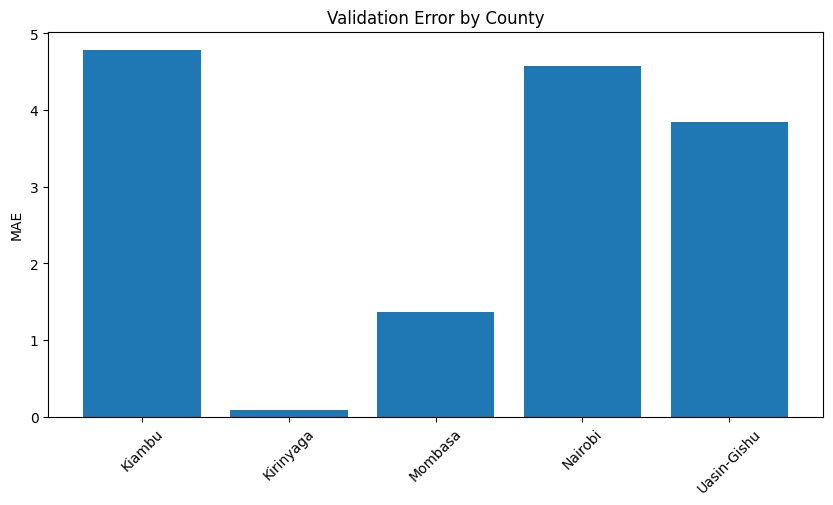

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(validation_df["County"], validation_df["final_error"])
plt.title("Validation Error by County")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.show()